# Plots for presentation

Same pie chart as `plots4paper.ipynb` (`pie_chart_variables`), but built from `metadata_summary_names.csv` (1803 total series) instead of `sef_series_summary_v2.csv` (1752 total series).

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import re
from matplotlib.lines import Line2D
import cartopy.crs as ccrs
import cartopy.feature as cfeature

plt.rcParams.update({
    "figure.figsize": (8, 5),
    "axes.grid": True,
    "axes.axisbelow": True,
    "axes.titlesize": 14,
    "axes.labelsize": 14,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 10,
    "figure.titlesize": 14
})


mapping = {
    'ta': 'Temperature',
    'p':  'Pressure',
    'dd': 'Wind Direction',
    'rr': 'Precipitation',
    'Tx': 'Maximum Temperature',
    'Tn': 'Minimum Temperature',
    'rh': 'Relative Humidity',
    'w': 'Wind Speed',
    'fs': 'Fresh Snow',
    'rrt': 'Type of Precipitation',
    'eee': 'Snow Depth',
    'other': 'Other'
}

# marker mapping
var_markers = {
    "ta": "o", # circle
    "p":  "D", # diamond
    "rr": "s", # square
    "dd": "p", # pentagon
    "w":  "*", # star
    "Tn": "v", # down arrow
    "Tx": "^", # up arrow
    "other": "X"  # or "h" (hexagon), "8" (octagon), etc.
}

OTHER_VARS = ["eee", "rrt", "fs", "rh", "w"]
OTHER_COLOR = '#aec7e8'  # gray-blue for "Other"

# Order of importance (Bottom of chart = First in list)
importance_order = ['ta', 'p', 'dd', 'rr', 'Tx', 'Tn', 'other']

# Define the Professional Color Map
color_map = {
    'Temperature': '#d62728',         # Strong Red
    'Maximum Temperature': '#ff7f0e', # Orange
    'Minimum Temperature': '#ffbb78', # Light Orange
    'Pressure': '#9467bd',            # Purple
    'Precipitation': '#1f77b4',       # Deep Blue
    'Wind Direction': '#2ca02c',      # Green
    'Wind Speed': '#9edae5',          # Sky Blue
    'Relative Humidity': '#17becf',   # Teal
    'Fresh Snow': '#dbdb8d',          # Pale Yellow/White-ish
    'Other' : OTHER_COLOR
}

MAP_DOMAIN = [-25, 61.5, 29.8, 73]
unibern = "#8a1e22" # color for the poster
unibern_red = "#e4003c"

# Pie Chart number of Series (from metadata, 1803 series)

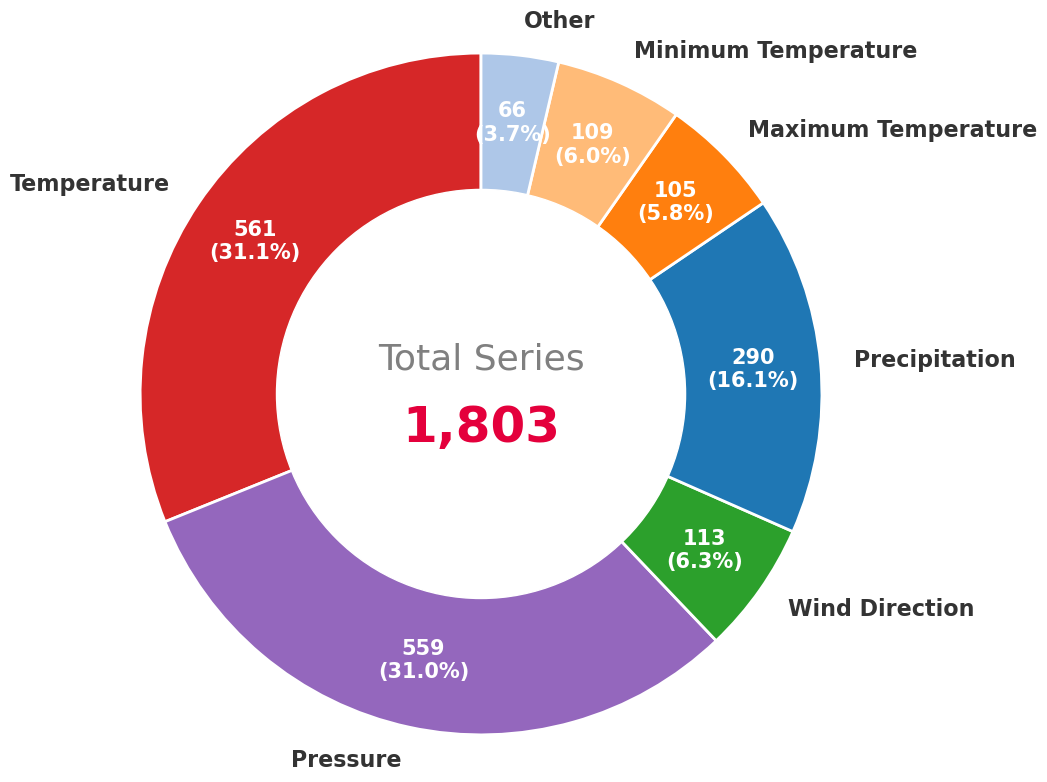

In [2]:
# Load and prep data from the metadata summary file (1803 total series)
df = pd.read_csv("metadata_summary_names.csv")

# Filter out variables we don't want
df_filtered = df.copy()
df_filtered["variable"] = df_filtered["Vbl"].apply(lambda v: "other" if v in OTHER_VARS else v)

# Count the number of series per variable
counts = df_filtered['variable'].value_counts().reset_index()
counts.columns = ['variable', 'count']

# Map to long names
counts['variable_long'] = counts['variable'].map(mapping).fillna("Other")

# Sort by importance order so the chart reads predictably clockwise
counts['sort_key'] = counts['variable'].apply(lambda x: importance_order.index(x) if x in importance_order else 99)
counts = counts.sort_values('sort_key')

# Extract plotting lists
labels = counts['variable_long'].tolist()  # names of variables
sizes = counts['count'].tolist()
colors = [OTHER_COLOR if label == "Other" else color_map.get(label, '#7f7f7f') for label in labels]
total_series = sum(sizes)

def count_and_pct(pct):
    # Re-calculate the absolute count from the percentage
    absolute = int(round(pct * total_series / 100.0))
    # Format with a newline character
    return f"{absolute}\n({pct:.1f}%)"

# 3. Create the Donut Chart
sns.set_theme(style="white")
fig, ax = plt.subplots(figsize=(10, 8))

# Plot the pie chart with a white edge to separate the slices cleanly
wedges, texts, autotexts = ax.pie(
    sizes, 
    labels=labels, 
    colors=colors,
    autopct=count_and_pct,
    startangle=90,           # Start at the top (12 o'clock)
    pctdistance=0.80,        # Position of the percentage text
    labeldistance=1.1,       # Position of the outer labels
    wedgeprops={'edgecolor': 'white', 'linewidth': 2} # The white borders between slices
)

# Customize the text for elegance
for text in texts:
    text.set_fontsize(16)
    text.set_fontweight('bold')
    text.set_color('#333333')

for autotext in autotexts:
    autotext.set_fontsize(15)
    autotext.set_fontweight('bold')
    autotext.set_color('white') # White text inside the colored slices usually looks crisp

# 4. Turn the Pie into a Donut
# Draw a white circle in the middle
centre_circle = plt.Circle((0,0), 0.60, fc='white')
fig.gca().add_artist(centre_circle)

# Add the Total Count in the center hole
ax.text(0, 0.1, "Total Series", ha='center', va='center', fontsize=26, color='gray')
ax.text(0, -0.1, f"{total_series:,}", ha='center', color=unibern_red,
        va='center', fontsize=36, fontweight='bold')

# 5. Final Polish
ax.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.

plt.tight_layout()
plt.savefig("image/pie_chart_variables_presentation.svg", bbox_inches='tight')
plt.savefig("image/pie_chart_variables_presentation.pdf", bbox_inches='tight')

plt.show()

# Evolution of Available Series (stacked) + Pie Chart — Combined Figure

Same combined figure as in `plots4poster.ipynb`, but saved under presentation-specific filenames so it doesn't overwrite the paper/poster versions.

## Timeseries: Number of Series over time

In [13]:
df_years = pd.read_csv("sef_active_years_1803.csv")
df_years["variable"] = df_years["variable"].apply(lambda v: "other" if v in OTHER_VARS else v)

# drop a handful of corrupted Year values from the raw SEF data (e.g. "183" instead of "1830")
df_years = df_years[(df_years["year"] >= 1600) & (df_years["year"] <= 2030)]

ts_by_var = (
    df_years
    .groupby(["year", "variable"])
    .size()
    .reset_index(name="n_series")
)

# Pivot the data so years are rows and variables are columns
ts_pivot = (
    ts_by_var.pivot(index='year', columns='variable', values='n_series').fillna(0)  # Fill missing combinations with 0
)

# filter by years of interest
ts_pivot = ts_pivot[ts_pivot.index < 1901]
ts_pivot.tail()

variable,Tn,Tx,dd,other,p,rr,ta
year,,,,,,,
1896,27.0,27.0,5.0,9.0,74.0,161.0,65.0
1897,26.0,26.0,6.0,10.0,82.0,161.0,66.0
1898,26.0,26.0,6.0,10.0,82.0,162.0,66.0
1899,25.0,25.0,6.0,10.0,83.0,162.0,66.0
1900,24.0,23.0,6.0,10.0,84.0,165.0,65.0


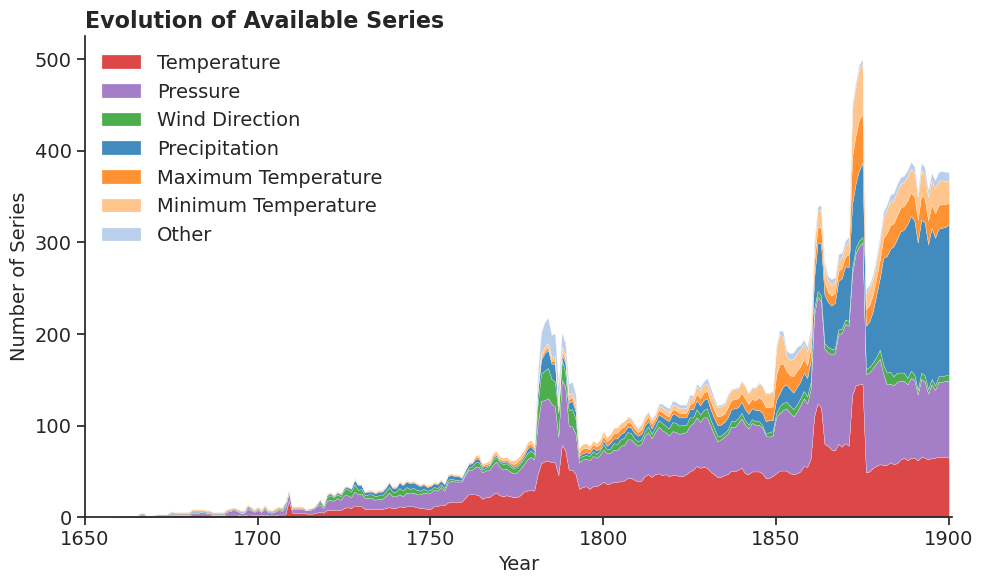

In [14]:
# Filter and Order columns based on importance (Bottom to Top)
plot_order = [v for v in importance_order if v in ts_pivot.columns]

ts_plot = ts_pivot[plot_order]

# Map columns to long names for the legend
labels = [mapping.get(v, v) for v in plot_order]
colors = [color_map.get(mapping.get(v, v), '#7f7f7f') for v in plot_order]

# Plotting
sns.set_theme(style="ticks")
fig, ax = plt.subplots(figsize=(10, 6))

# Use stackplot for a clean, professional "accumulation" look
ax.stackplot(
    ts_plot.index, 
    ts_plot.values.T, # transpose the matrix to match (n_vars, n_years)
    labels=labels, 
    colors=colors, 
    alpha=0.85,
    edgecolor='white',
    linewidth=0.2
)

# Legend (Reversed to show 'ta' at the top of the legend)
handles, labels = ax.get_legend_handles_labels()
ax.legend(
    handles, 
    labels, 
    loc='upper left', 
    fontsize=14,
    bbox_to_anchor=(0, 1),
    frameon=False
)

# Final Polish
ax.set_title("Evolution of Available Series", fontsize=16,
             fontweight='bold', loc='left')
ax.set_xlabel("Year", fontsize=14)
ax.set_xlim(1650, 1901)
ax.set_ylabel("Number of Series", fontsize=14)
ax.set_ylim(0)
ax.tick_params(axis='both', labelsize=14)
sns.despine()

plt.tight_layout()
plt.savefig("image/series_over_time_stacked-presentation.svg", bbox_inches='tight')
plt.savefig("image/series_over_time_stacked-presentation.pdf", bbox_inches='tight')

plt.show()

## Compact pie chart (for overlay) — from metadata, 1803 series

Big-count-only style (no outer labels), sized to sit as an inset on the stacked plot.

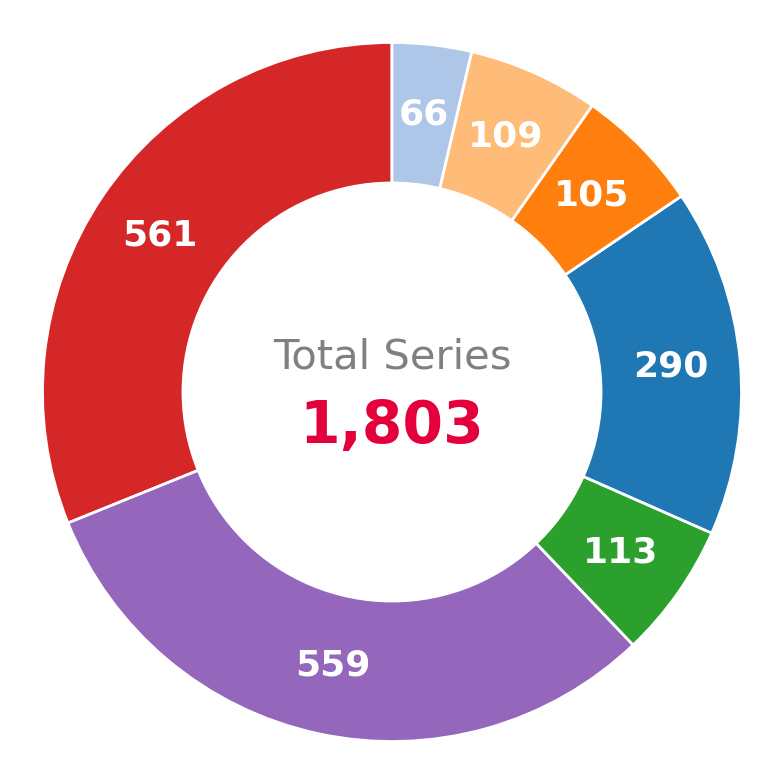

In [15]:
# Load and prep data from the metadata summary file (1803 total series)
df = pd.read_csv("metadata_summary_names.csv")
df_filtered = df.copy()
df_filtered["variable"] = df_filtered["Vbl"].apply(lambda v: "other" if v in OTHER_VARS else v)

# Count the number of series per variable
counts = df_filtered['variable'].value_counts().reset_index()
counts.columns = ['variable', 'count']

# Map to long names
counts['variable_long'] = counts['variable'].map(mapping).fillna("Other")

# Sort by importance order so the chart reads predictably clockwise
counts['sort_key'] = counts['variable'].apply(lambda x: importance_order.index(x) if x in importance_order else 99)
counts = counts.sort_values('sort_key')

# Extract plotting lists
labels = counts['variable_long'].tolist()
sizes = counts['count'].tolist()
colors = [OTHER_COLOR if label == "Other" else color_map.get(label, '#7f7f7f') for label in labels]
total_series = sum(sizes)

def count_and_pct(pct):
    absolute = int(round(pct * total_series / 100.0))
    return f"{absolute}"

# Create the Donut Chart
sns.set_theme(style="white")
fig, ax = plt.subplots(figsize=(8, 8))
wedges, texts, autotexts = ax.pie(
    sizes,
    colors=colors,
    autopct=count_and_pct,
    startangle=90,
    pctdistance=0.80,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)

for autotext in autotexts:
    autotext.set_fontsize(26)
    autotext.set_fontweight('bold')
    autotext.set_color('white')

centre_circle = plt.Circle((0,0), 0.60, fc='white')
fig.gca().add_artist(centre_circle)

ax.text(0, 0.1, "Total Series", ha='center', va='center', fontsize=30, color='gray')
ax.text(0, -0.1, f"{total_series:,}", ha='center', color=unibern_red,
        va='center', fontsize=42, fontweight='bold')

ax.axis('equal')
plt.tight_layout()
plt.savefig("image/pie_chart_variables-biglabel_presentation.svg", bbox_inches='tight')
plt.savefig("image/pie_chart_variables-biglabel_presentation.pdf", bbox_inches='tight')
plt.show()

## Combine the figures

In [16]:
import cairosvg
from PIL import Image
from io import BytesIO
from IPython.display import display

In [17]:
DPI_SCALE = 4  # 4x for ~300dpi

# Convert SVGs to high-res PNGs
bg_png = cairosvg.svg2png(url="image/series_over_time_stacked-presentation.svg", scale=DPI_SCALE)
fg_png = cairosvg.svg2png(url="image/pie_chart_variables-biglabel_presentation.svg", scale=DPI_SCALE)

bg = Image.open(BytesIO(bg_png)).convert("RGBA")
fg = Image.open(BytesIO(fg_png)).convert("RGBA")

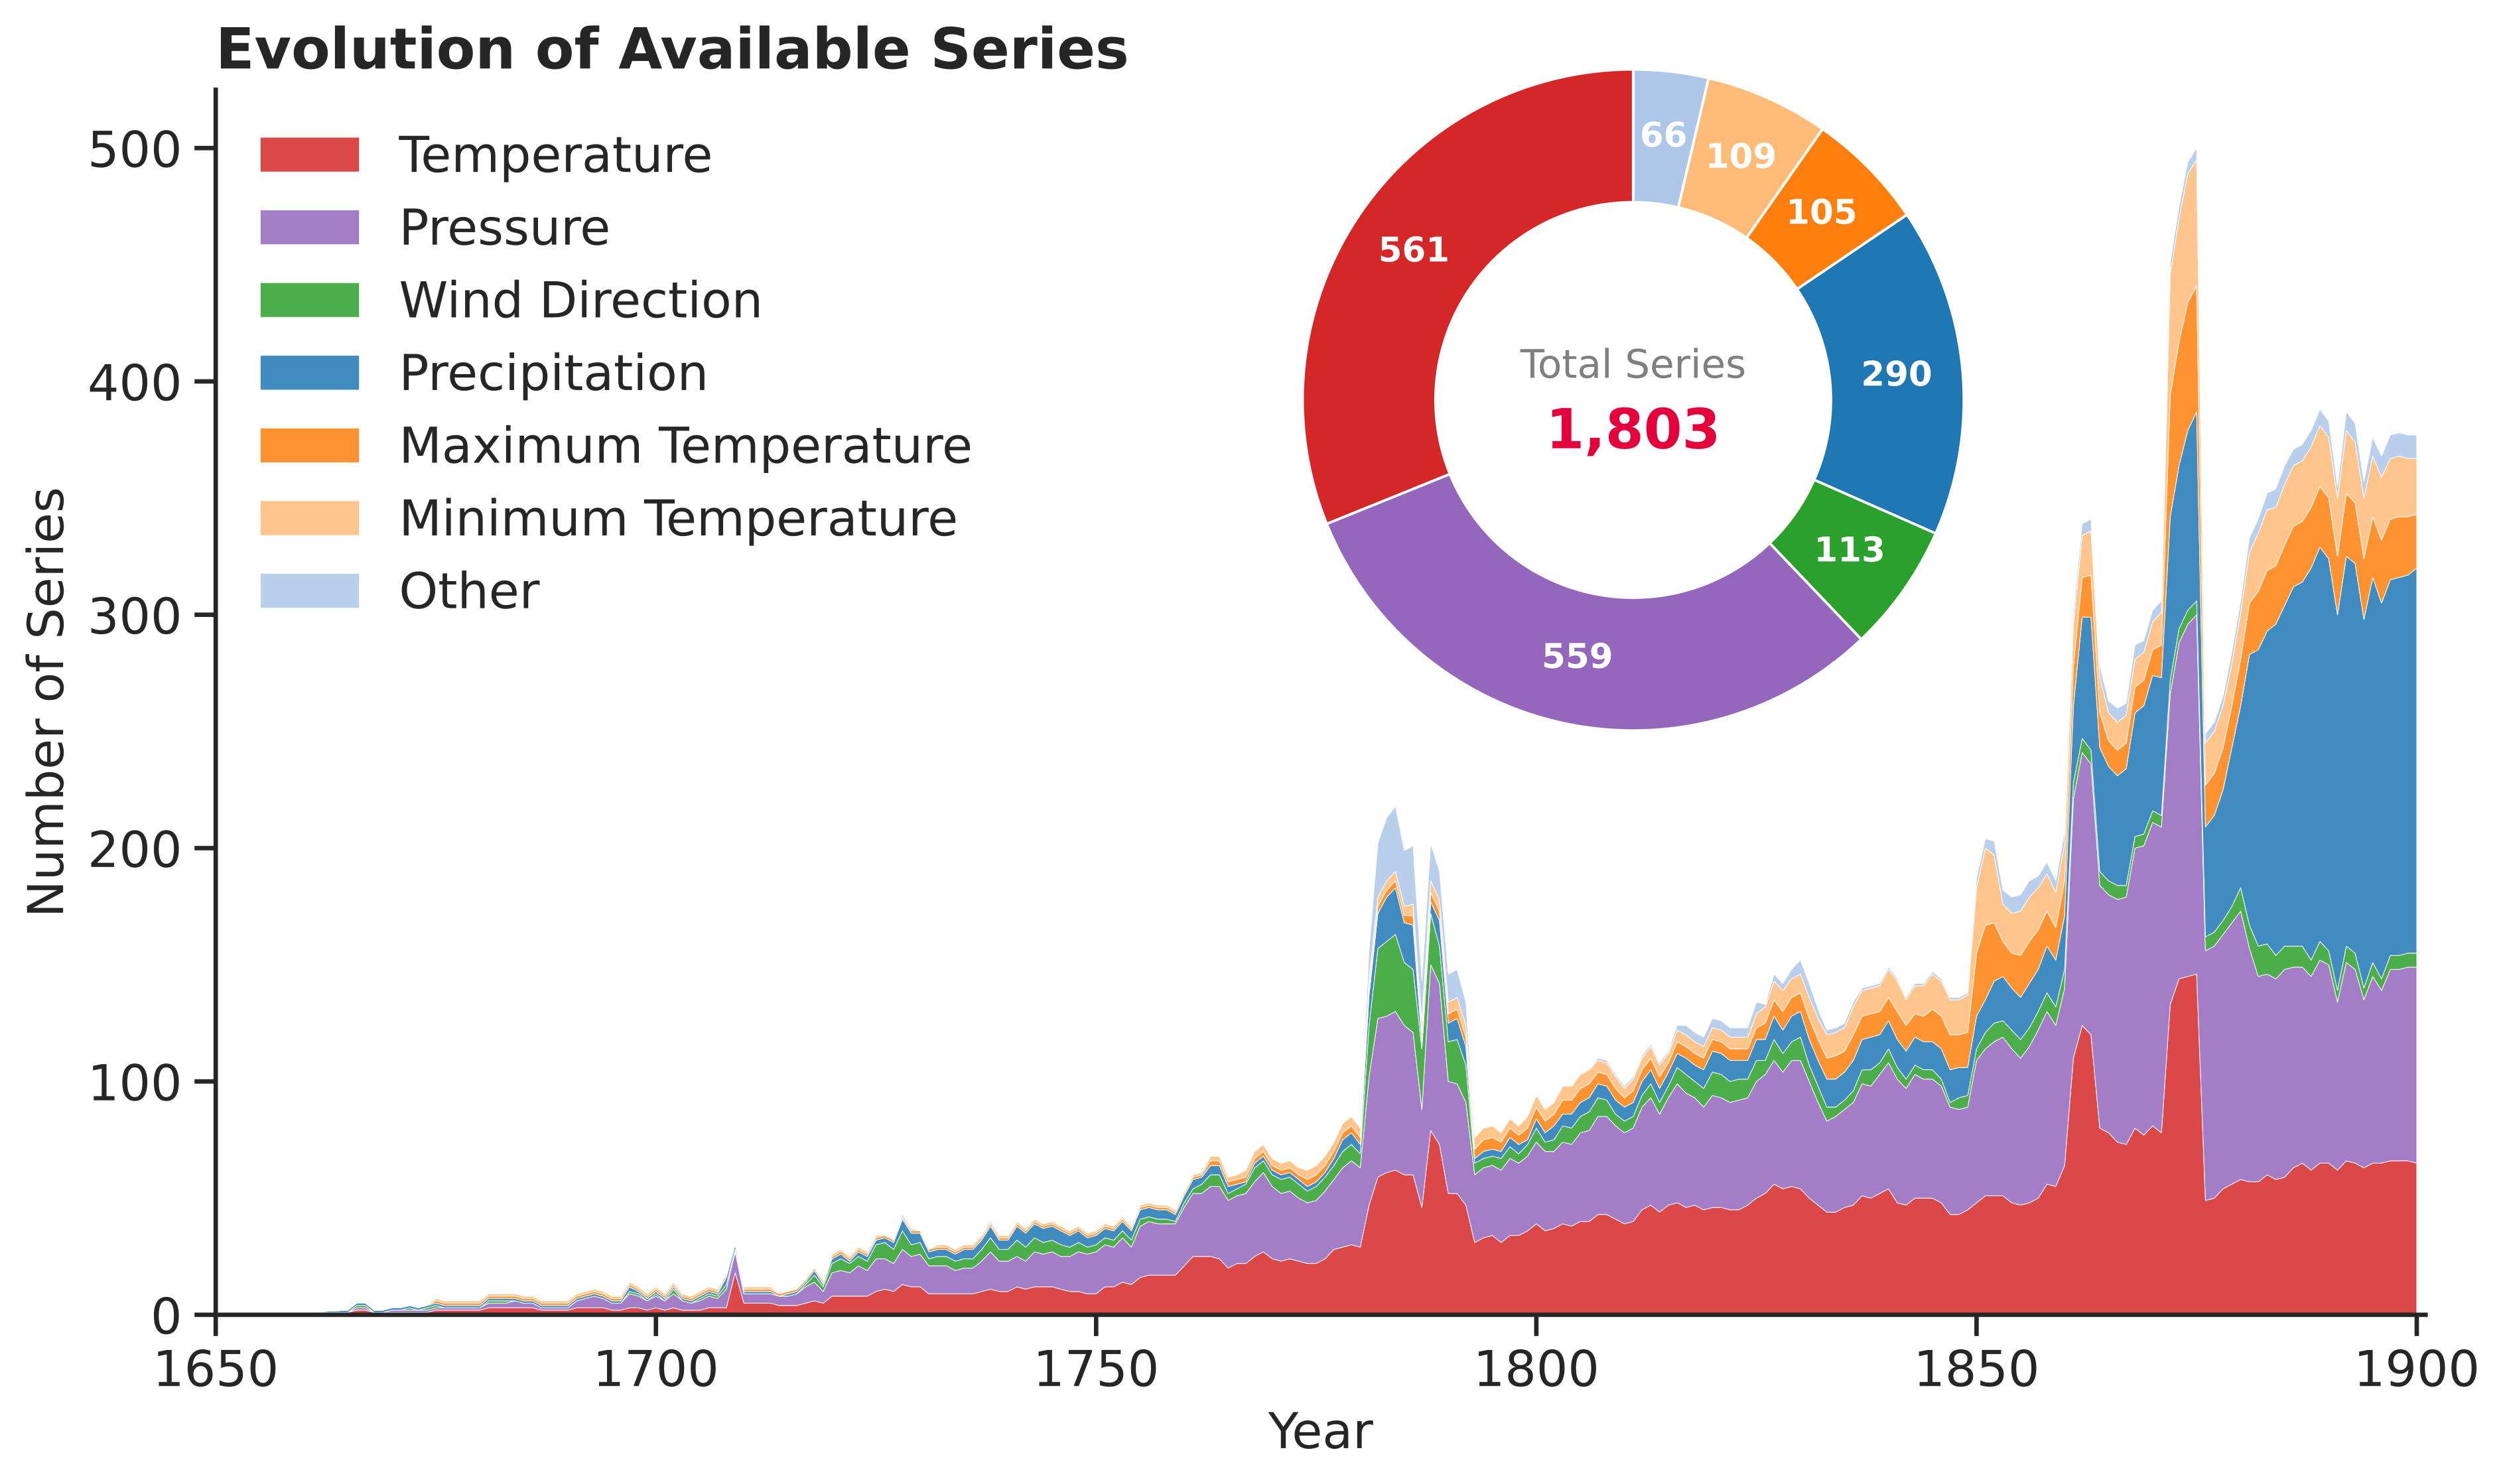

In [18]:
# Scale pie to ~50% of background height
target_h = int(bg.height * 0.5)
ratio = target_h / fg.height
fg_resized = fg.resize((int(fg.width * ratio), target_h), Image.LANCZOS)

# Position: upper-right corner with a small margin
x = bg.width - fg_resized.width - int(bg.width * 0.2)
y = int(bg.height * 0.02)

# Composite and save
bg.paste(fg_resized, (x, y), fg_resized)
bg.save("image/combined_figure_presentation.png", dpi=(300, 300))
bg.convert("RGB").save("image/combined_figure_presentation.pdf", dpi=(300, 300))
display(bg)